In [2]:
import pandas as pd
import numpy as np
import json

df = pd.read_json(
    "candidates.jsonl",
    lines=True
)

print(df.shape)
df.head()

(100000, 8)


,candidate_id,profile,career_history,education,skills,certifications,languages,redrob_signals
0,CAND_0000001,"{'anonymized_name': 'Ira Vora', 'headline': 'B...","[{'company': 'Mindtree', 'title': 'Backend Eng...",[{'institution': 'Lovely Professional Universi...,"[{'name': 'Tailwind', 'proficiency': 'intermed...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 86.9, 'signup_d..."
1,CAND_0000002,"{'anonymized_name': 'Saanvi Sethi', 'headline'...","[{'company': 'Wipro', 'title': 'Operations Man...","[{'institution': 'Local Engineering College', ...","[{'name': 'Project Management', 'proficiency':...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 78.7, 'signup_d..."
2,CAND_0000003,"{'anonymized_name': 'Yash Agarwal', 'headline'...","[{'company': 'TCS', 'title': 'Customer Support...","[{'institution': 'Local Engineering College', ...","[{'name': 'Angular', 'proficiency': 'intermedi...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 31.9, 'signup_d..."
3,CAND_0000004,"{'anonymized_name': 'Anil Bose', 'headline': '...","[{'company': 'Dunder Mifflin', 'title': 'Marke...","[{'institution': 'Local Engineering College', ...","[{'name': 'Node.js', 'proficiency': 'intermedi...","[{'name': 'AWS Certified Cloud Practitioner', ...","[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 28.5, 'signup_d..."
4,CAND_0000005,"{'anonymized_name': 'Aisha Sethi', 'headline':...","[{'company': 'Stark Industries', 'title': 'Acc...","[{'institution': 'Chandigarh University', 'deg...","[{'name': 'SQL', 'proficiency': 'beginner', 'e...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 84.6, 'signup_d..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   candidate_id    100000 non-null  str   
 1   profile         100000 non-null  object
 2   career_history  100000 non-null  object
 3   education       100000 non-null  object
 4   skills          100000 non-null  object
 5   certifications  100000 non-null  object
 6   languages       100000 non-null  object
 7   redrob_signals  100000 non-null  object
dtypes: object(7), str(1)
memory usage: 6.1+ MB


In [4]:
df.columns

Index(['candidate_id', 'profile', 'career_history', 'education', 'skills',
       'certifications', 'languages', 'redrob_signals'],
      dtype='str')

In [5]:
print("Total rows:", len(df))
print("Unique IDs:", df['candidate_id'].nunique())
print("Duplicate IDs:", df['candidate_id'].duplicated().sum())

Total rows: 100000
Unique IDs: 100000
Duplicate IDs: 0


In [6]:
df.isnull().sum()

candidate_id      0
profile           0
career_history    0
education         0
skills            0
certifications    0
languages         0
redrob_signals    0
dtype: int64

In [7]:
candidate = df.iloc[0]
print(json.dumps(candidate.to_dict(), indent=2))

{
  "candidate_id": "CAND_0000001",
  "profile": {
    "anonymized_name": "Ira Vora",
    "headline": "Backend Engineer | SQL, Spark, Cloud",
    "summary": "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid \u2014 Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side \u2014 Python, SQL, Spark, Airflow, warehouse design \u2014 and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
    "location": "Toronto",
    "country": "Canada",
    "years_of_experience": 6.9,
    "current_title": "Backend Engineer",
    "current_company": "Mindtree",
    "current_company_size": "1

In [8]:
type(df['profile'][0])
type(df['career_history'][0])
type(df['education'][0])
type(df['skills'][0])
type(df['redrob_signals'][0])

dict

In [9]:
df['profile'][0].keys()

dict_keys(['anonymized_name', 'headline', 'summary', 'location', 'country', 'years_of_experience', 'current_title', 'current_company', 'current_company_size', 'current_industry'])

In [10]:
df['career_history'][0][0].keys()

dict_keys(['company', 'title', 'start_date', 'end_date', 'duration_months', 'is_current', 'industry', 'company_size', 'description'])

In [11]:
df['education'][0][0].keys()

dict_keys(['institution', 'degree', 'field_of_study', 'start_year', 'end_year', 'grade', 'tier'])

In [12]:
df['redrob_signals'][0].keys()

dict_keys(['profile_completeness_score', 'signup_date', 'last_active_date', 'open_to_work_flag', 'profile_views_received_30d', 'applications_submitted_30d', 'recruiter_response_rate', 'avg_response_time_hours', 'skill_assessment_scores', 'connection_count', 'endorsements_received', 'notice_period_days', 'expected_salary_range_inr_lpa', 'preferred_work_mode', 'willing_to_relocate', 'github_activity_score', 'search_appearance_30d', 'saved_by_recruiters_30d', 'interview_completion_rate', 'offer_acceptance_rate', 'verified_email', 'verified_phone', 'linkedin_connected'])

In [13]:
df['num_skills'] = df['skills'].apply(
    lambda x: len(x) if isinstance(x,list) else 0
)
df['num_skills'].describe()

count    100000.00000
mean          9.60302
std           3.31163
min           5.00000
25%           7.00000
50%           9.00000
75%          11.00000
max          23.00000
Name: num_skills, dtype: float64

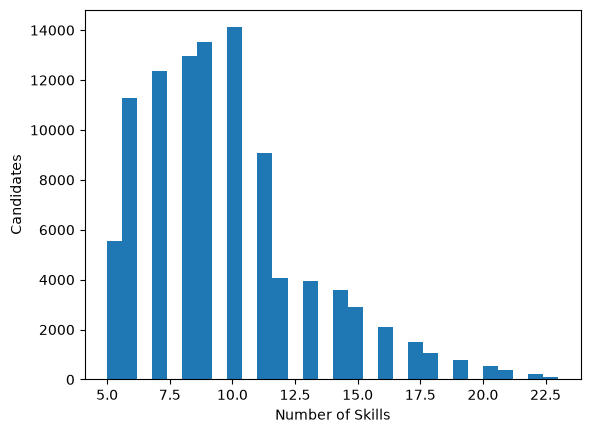

In [14]:
import matplotlib.pyplot as plt

plt.hist(df['num_skills'], bins=30)
plt.xlabel("Number of Skills")
plt.ylabel("Candidates")
plt.show()

In [15]:
df['num_jobs'] = df['career_history'].apply(
    lambda x: len(x) if isinstance(x,list) else 0
)

df['num_jobs'].describe()

count    100000.000000
mean          3.001710
std           1.522442
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           9.000000
Name: num_jobs, dtype: float64

In [16]:
signal_keys = df['redrob_signals'][0].keys()
print(signal_keys)

dict_keys(['profile_completeness_score', 'signup_date', 'last_active_date', 'open_to_work_flag', 'profile_views_received_30d', 'applications_submitted_30d', 'recruiter_response_rate', 'avg_response_time_hours', 'skill_assessment_scores', 'connection_count', 'endorsements_received', 'notice_period_days', 'expected_salary_range_inr_lpa', 'preferred_work_mode', 'willing_to_relocate', 'github_activity_score', 'search_appearance_30d', 'saved_by_recruiters_30d', 'interview_completion_rate', 'offer_acceptance_rate', 'verified_email', 'verified_phone', 'linkedin_connected'])


In [17]:
signal_df = pd.json_normalize(df['redrob_signals'])
signal_df.describe()

,profile_completeness_score,profile_views_received_30d,applications_submitted_30d,recruiter_response_rate,avg_response_time_hours,connection_count,endorsements_received,notice_period_days,github_activity_score,search_appearance_30d,...,skill_assessment_scores.Python,skill_assessment_scores.OpenSearch,skill_assessment_scores.BM25,skill_assessment_scores.scikit-learn,skill_assessment_scores.pgvector,skill_assessment_scores.Embeddings,skill_assessment_scores.LlamaIndex,skill_assessment_scores.PyTorch,skill_assessment_scores.Deep Learning,skill_assessment_scores.QLoRA
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,312.000000,319.000000,309.000000,317.000000,340.000000,327.000000,291.000000,340.000000,284.000000,329.000000
mean,56.758180,47.98525,5.390360,0.436574,132.702744,345.664890,30.068570,87.385800,9.619230,117.543800,...,55.622756,56.154545,54.788673,55.394637,53.963824,55.326300,56.498969,55.172941,55.250000,54.979939
std,17.274069,32.05187,3.494796,0.214122,75.238241,208.145694,20.242847,36.589628,17.761394,92.825891,...,15.479409,15.694668,14.676334,15.308230,15.726004,15.133801,15.643911,15.729964,15.028424,15.508736
min,25.000000,0.00000,0.000000,0.020000,2.100000,10.000000,0.000000,0.000000,-1.000000,0.000000,...,25.300000,25.100000,25.100000,25.200000,25.600000,25.200000,25.000000,25.100000,26.900000,25.000000
25%,42.200000,23.00000,2.000000,0.250000,68.300000,174.000000,14.000000,60.000000,-1.000000,52.000000,...,43.750000,43.400000,43.500000,42.900000,41.250000,43.250000,44.950000,43.100000,42.375000,43.000000
50%,56.800000,45.00000,5.000000,0.440000,129.900000,335.000000,28.000000,90.000000,-1.000000,105.000000,...,55.550000,55.700000,53.400000,56.100000,53.600000,55.100000,56.000000,55.850000,54.150000,54.000000
75%,71.600000,68.00000,8.000000,0.620000,193.300000,497.000000,43.000000,120.000000,16.700000,158.000000,...,68.925000,69.350000,66.800000,68.600000,66.125000,68.350000,68.450000,67.350000,67.100000,67.800000
max,99.900000,374.00000,24.000000,0.950000,280.000000,1898.000000,242.000000,150.000000,96.900000,1490.000000,...,92.000000,90.500000,91.800000,89.900000,88.600000,92.900000,96.100000,91.000000,94.000000,88.800000


In [18]:
profile = df['profile'][0]

print(type(profile))
print(profile.keys())
print(json.dumps(profile, indent=2))

<class 'dict'>
dict_keys(['anonymized_name', 'headline', 'summary', 'location', 'country', 'years_of_experience', 'current_title', 'current_company', 'current_company_size', 'current_industry'])
{
  "anonymized_name": "Ira Vora",
  "headline": "Backend Engineer | SQL, Spark, Cloud",
  "summary": "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid \u2014 Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side \u2014 Python, SQL, Spark, Airflow, warehouse design \u2014 and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
  "location": "Toronto",
  "country": "Canada",
  

In [19]:
career = df['career_history'][0]

print(type(career))
print(len(career))

print(json.dumps(career[0], indent=2))

<class 'list'>
2
{
  "company": "Mindtree",
  "title": "Backend Engineer",
  "start_date": "2024-03-08",
  "end_date": null,
  "duration_months": 27,
  "is_current": true,
  "industry": "IT Services",
  "company_size": "10001+",
  "description": "Implemented streaming data pipelines on Kafka and Spark Streaming for a real-time user-activity processing platform. Designed the schema-registry integration, the watermark/state management approach, and the deduplication logic for late-arriving events. Worked closely with the data science team to make sure feature pipelines aligned with what their models needed. Most of my career has been data engineering, with some adjacent ML exposure."
}


In [20]:
education = df['education'][0]

print(type(education))
print(len(education))

print(json.dumps(education[0], indent=2))

<class 'list'>
1
{
  "institution": "Lovely Professional University",
  "degree": "B.E.",
  "field_of_study": "Computer Science",
  "start_year": 2017,
  "end_year": 2020,
  "grade": "8.24 CGPA",
  "tier": "tier_3"
}


In [21]:
skills = df['skills'][0]

print(type(skills))
print(len(skills))

print(json.dumps(skills[0], indent=2))

<class 'list'>
17
{
  "name": "Tailwind",
  "proficiency": "intermediate",
  "endorsements": 3,
  "duration_months": 13
}


In [23]:
certs = df['certifications'][0]

if certs:
    print(json.dumps(certs[0], indent=2))
else:
    print("No certifications found for this candidate.")

No certifications found for this candidate.


In [25]:
langs = df['languages'][0]

if langs:
    print(json.dumps(langs, indent=2))

[
  {
    "language": "English",
    "proficiency": "professional"
  },
  {
    "language": "Hindi",
    "proficiency": "conversational"
  }
]


In [28]:
signal_df['recruiter_response_rate'].describe()

count    100000.000000
mean          0.436574
std           0.214122
min           0.020000
25%           0.250000
50%           0.440000
75%           0.620000
max           0.950000
Name: recruiter_response_rate, dtype: float64

In [29]:
signal_df['github_activity_score'].describe()

count    100000.000000
mean          9.619230
std          17.761394
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          16.700000
max          96.900000
Name: github_activity_score, dtype: float64

In [30]:
signal_df['interview_completion_rate'].describe()

count    100000.000000
mean          0.619510
std           0.170662
min           0.300000
25%           0.480000
50%           0.620000
75%           0.760000
max           1.000000
Name: interview_completion_rate, dtype: float64

In [31]:
signal_df['notice_period_days'].describe()

count    100000.000000
mean         87.385800
std          36.589628
min           0.000000
25%          60.000000
50%          90.000000
75%         120.000000
max         150.000000
Name: notice_period_days, dtype: float64

In [32]:
signal_df['last_active_date'].head()

0    2026-05-20
1    2025-11-12
2    2026-03-21
3    2026-03-25
4    2025-10-01
Name: last_active_date, dtype: str

In [33]:
signal_df['signup_date'].head()

0    2025-10-16
1    2025-07-28
2    2024-08-02
3    2025-07-21
4    2023-10-07
Name: signup_date, dtype: str